Initial Weights + Bias:
Weights: [-0.25091976  0.90142861]
Bias: 0.000

Training Single Perceptron (AND Gate)...
Iteration    0: Loss = 0.497929
Iteration 1000: Loss = 0.352482
Iteration 2000: Loss = 0.299640

Training Complete!
Final Weights: W1=1.315, W2=1.454
Final Bias: -2.272

Predictions (AND Gate):
Input: [0, 0] → Pred: 0.093 (0)
Input: [0, 1] → Pred: 0.306 (0)
Input: [1, 0] → Pred: 0.277 (0)
Input: [1, 1] → Pred: 0.622 (1)


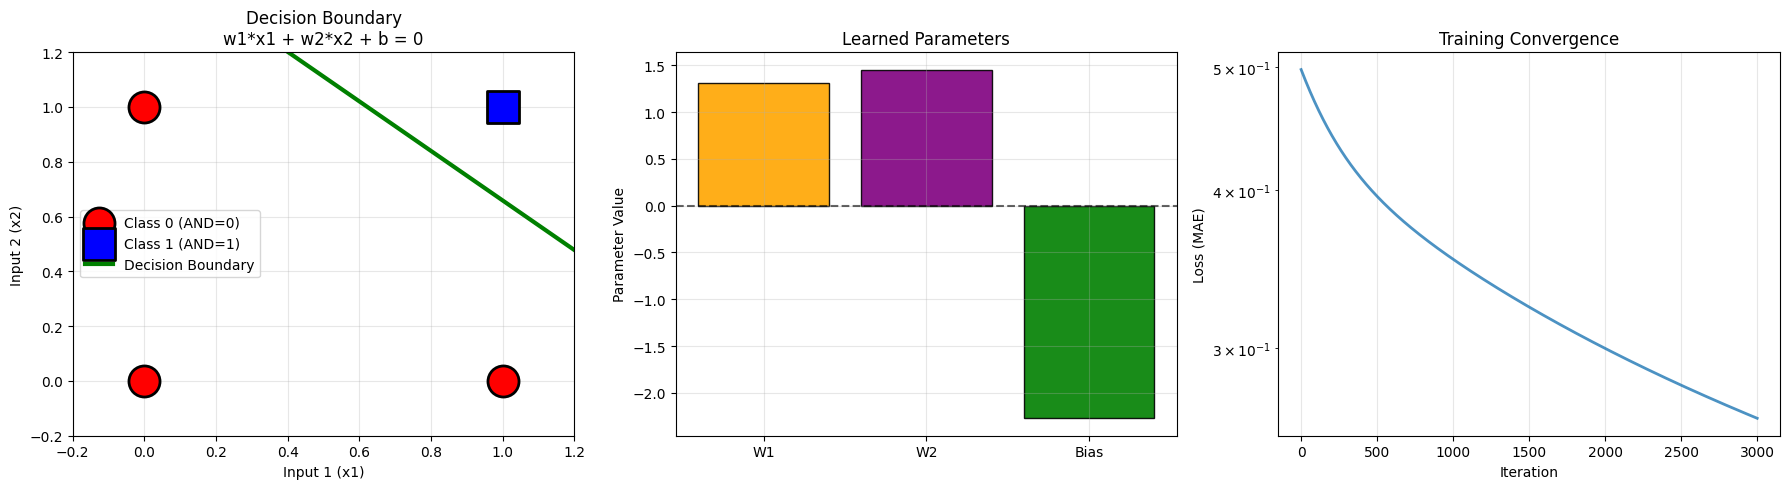


DECISION BOUNDARY VERIFICATION:
Equation: (1.315)*x1 + (1.454)*x2 + (-2.272) = 0
Solved for x2: x2 = (-1.315*x1 - (-2.272)) / 1.454

Point positions relative to boundary:
[0, 0]: -2.272044 → Below (Class 0)
[0, 1]: -0.818019 → Below (Class 0)
[1, 0]: -0.957243 → Below (Class 0)
[1, 1]: 0.496782 → Above (Class 1)


In [1]:
#AND GATE WITH TRAINED WEIGHTS
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# AND dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])

# Initialize
np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.array([[0.0]])

print("Initial Weights + Bias:")
print(f"Weights: {weights.flatten()}")
print(f"Bias: {bias[0,0]:.3f}")

# Activation and derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(output):
    # derivative w.r.t. output (sigmoid(output_input))
    return output * (1 - output)

def predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return sigmoid(linear)

# Training loop (single neuron)
print("\nTraining Single Perceptron (AND Gate)...")
loss_history = []

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias            # shape (4,1)
    output = sigmoid(linear_output)                      # shape (4,1)
    error = y - output                                   # shape (4,1)
    d_output = error * sigmoid_derivative(output)        # shape (4,1)

    # Gradient descent parameter update
    weights += learning_rate * np.dot(X.T, d_output)     # (2,4) x (4,1) -> (2,1)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)  # (1,1)

    current_loss = np.mean(np.abs(error))                # MAE
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration:4d}: Loss = {current_loss:.6f}")

print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0,0]:.3f}, W2={weights[1,0]:.3f}")
print(f"Final Bias: {bias[0,0]:.3f}")

# Final predictions
final_predictions = predict(X, weights, bias)

print("\nPredictions (AND Gate):")
for i in range(len(X)):
    pred_prob = final_predictions[i, 0]
    pred_class = 1 if pred_prob > 0.5 else 0
    print(f"Input: [{X[i,0]:.0f}, {X[i,1]:.0f}] → Pred: {pred_prob:.3f} ({pred_class})")

# Visualization
plt.figure(figsize=(18, 5))

# Subplot 1: decision boundary & points
plt.subplot(1, 3, 1)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            s=500, marker='o', edgecolors='black', linewidth=2, label='Class 0 (AND=0)', color='red', zorder=3)
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            s=500, marker='s', edgecolors='black', linewidth=2, label='Class 1 (AND=1)', color='blue', zorder=4)

w1, w2 = weights[0,0], weights[1,0]
b = bias[0,0]
x1_boundary = np.linspace(-0.2, 1.2, 200)
if abs(w2) > 1e-8:
    x2_boundary = (-w1 * x1_boundary - b) / w2
    plt.plot(x1_boundary, x2_boundary, 'g-', linewidth=3, label='Decision Boundary', zorder=2)
else:
    # vertical boundary
    plt.axvline(x=-b/w1, color='g', linewidth=3, label='Decision Boundary')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('Decision Boundary\nw1*x1 + w2*x2 + b = 0')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: learned parameters
plt.subplot(1, 3, 2)
params = ['W1', 'W2', 'Bias']
values = [w1, w2, b]
plt.bar(params, values, color=['orange', 'purple', 'green'], alpha=0.9, edgecolor='black')
plt.ylabel('Parameter Value')
plt.title('Learned Parameters')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.6)
plt.grid(True, alpha=0.3)

# Subplot 3: loss curve
plt.subplot(1, 3, 3)
plt.semilogy(loss_history, linewidth=2, alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss (MAE)')
plt.title('Training Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verification prints
print(f"\nDECISION BOUNDARY VERIFICATION:")
print(f"Equation: ({w1:.3f})*x1 + ({w2:.3f})*x2 + ({b:.3f}) = 0")
if abs(w2) > 1e-8:
    print(f"Solved for x2: x2 = (-{w1:.3f}*x1 - ({b:.3f})) / {w2:.3f}")
else:
    print("Vertical boundary (w2 approximately 0).")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = w1 * X[i, 0] + w2 * X[i, 1] + b
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f"[{X[i,0]:.0f}, {X[i,1]:.0f}]: {point_value:.6f} → {side}")
